In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import joblib

In [113]:
#working with BRFSS dataset
df = pd.read_csv("BRFSS_2024_subset3.csv")

In [114]:
#displaying data
df.head()

,SEXVAR,GENHLTH,EXERANY2,CHCKDNY2,DIABETE4,INCOME3,SMOKE100,DIABTYPE,INSULIN1,CHKHEMO3,...,_RACE,_RACEGR3,_RACEPRV,_SEX,_AGEG5YR,_AGE65YR,_BMI5,_BMI5CAT,_RFBMI5,DRNKANY6
0,2.0,3.0,1.0,2.0,3.0,99.0,2.0,NaN,NaN,NaN,...,1.0,1.0,1.0,2.0,12.0,2.0,2249.0,2.0,1.0,2.0
1,1.0,1.0,1.0,2.0,3.0,11.0,1.0,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,13.0,2.0,2583.0,3.0,2.0,2.0
2,1.0,2.0,1.0,2.0,3.0,99.0,1.0,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,8.0,1.0,2253.0,2.0,1.0,1.0
3,1.0,1.0,1.0,2.0,3.0,6.0,2.0,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,13.0,2.0,2509.0,3.0,2.0,2.0
4,1.0,3.0,2.0,2.0,3.0,3.0,2.0,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,6.0,1.0,1977.0,2.0,1.0,2.0


In [115]:
#list column names
orig_column_names = df.columns.tolist()
print(orig_column_names)

['SEXVAR', 'GENHLTH', 'EXERANY2', 'CHCKDNY2', 'DIABETE4', 'INCOME3', 'SMOKE100', 'DIABTYPE', 'INSULIN1', 'CHKHEMO3', '_TOTINDA', '_RACE', '_RACEGR3', '_RACEPRV', '_SEX', '_AGEG5YR', '_AGE65YR', '_BMI5', '_BMI5CAT', '_RFBMI5', 'DRNKANY6']


In [116]:
#renaming column names to avoid confusion
df.columns = ["sex", "health", "physically active", "kidney disease", 
              "diabetes", "income", "smoker", "diabtype", "insulin", "hemoglobin",
              "totinda", "race", "_racegr3", "_racerv", "_sex", "age", "age65yr", "BMI",
              "BMI categories", "obese", "alcohol_30"]

In [117]:
df.head()

,sex,health,physically active,kidney disease,diabetes,income,smoker,diabtype,insulin,hemoglobin,...,race,_racegr3,_racerv,_sex,age,age65yr,BMI,BMI categories,obese,alcohol_30
0,2.0,3.0,1.0,2.0,3.0,99.0,2.0,NaN,NaN,NaN,...,1.0,1.0,1.0,2.0,12.0,2.0,2249.0,2.0,1.0,2.0
1,1.0,1.0,1.0,2.0,3.0,11.0,1.0,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,13.0,2.0,2583.0,3.0,2.0,2.0
2,1.0,2.0,1.0,2.0,3.0,99.0,1.0,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,8.0,1.0,2253.0,2.0,1.0,1.0
3,1.0,1.0,1.0,2.0,3.0,6.0,2.0,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,13.0,2.0,2509.0,3.0,2.0,2.0
4,1.0,3.0,2.0,2.0,3.0,3.0,2.0,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,6.0,1.0,1977.0,2.0,1.0,2.0


In [118]:
#check missing values
df.isna().sum()

sex                       0
health                    5
physically active         3
kidney disease            6
diabetes                  4
income                 9269
smoker                28860
diabtype             443852
insulin              443855
hemoglobin           443859
totinda                   0
race                      0
_racegr3                  0
_racerv                   0
_sex                      0
age                       0
age65yr                   0
BMI                   43037
BMI categories        43037
obese                     0
alcohol_30                0
dtype: int64

In [119]:
#drop duplicate and unwanted columns for better data review
df = df.drop([
    "BMI categories", "age65yr", "diabtype", "insulin", "hemoglobin",
    "_racegr3", "_racerv", "_sex", "totinda"], axis=1)

In [120]:
new_columns = df.columns.tolist()
print(new_columns)

['sex', 'health', 'physically active', 'kidney disease', 'diabetes', 'income', 'smoker', 'race', 'age', 'BMI', 'obese', 'alcohol_30']


In [121]:
df.isna().sum()

sex                      0
health                   5
physically active        3
kidney disease           6
diabetes                 4
income                9269
smoker               28860
race                     0
age                      0
BMI                  43037
obese                    0
alcohol_30               0
dtype: int64

In [122]:
#check for NaNs
nan_columns = df.columns[df.isna().any()].tolist()
print(nan_columns)

['health', 'physically active', 'kidney disease', 'diabetes', 'income', 'smoker', 'BMI']


In [123]:
#checking all for zero's
df.eq(0).sum()

sex                  0
health               0
physically active    0
kidney disease       0
diabetes             0
income               0
smoker               0
race                 0
age                  0
BMI                  0
obese                0
alcohol_30           0
dtype: int64

In [124]:
df.describe()

,sex,health,physically active,kidney disease,diabetes,income,smoker,race,age,BMI,obese,alcohol_30
count,457670.000000,457665.000000,457667.000000,457664.000000,457666.000000,448401.000000,428810.000000,457670.000000,457670.000000,414633.000000,457670.000000,457670.000000
mean,1.524795,2.659362,1.251427,1.970784,2.739718,21.215446,1.643007,2.287550,7.781845,2855.680093,2.377628,2.196764
std,0.499385,1.081163,0.547624,0.415151,0.765308,31.355378,0.667560,2.511348,3.738928,658.616131,2.178472,2.226566
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1200.000000,1.000000,1.000000
25%,1.000000,2.000000,1.000000,2.000000,3.000000,6.000000,1.000000,1.000000,5.000000,2414.000000,1.000000,1.000000
50%,2.000000,3.000000,1.000000,2.000000,3.000000,8.000000,2.000000,1.000000,8.000000,2744.000000,2.000000,2.000000
75%,2.000000,3.000000,1.000000,2.000000,3.000000,10.000000,2.000000,2.000000,11.000000,3175.000000,2.000000,2.000000
max,2.000000,9.000000,9.000000,9.000000,9.000000,99.000000,9.000000,9.000000,14.000000,9984.000000,9.000000,9.000000


In [125]:
df.skew()

sex                 -0.099303
health               0.507629
physically active    5.490579
kidney disease       8.735095
diabetes            -0.974926
income               1.779436
smoker               3.945614
race                 1.726225
age                 -0.264600
BMI                  1.421010
obese                2.567438
alcohol_30           2.540594
dtype: float64

In [126]:
df.kurtosis()

sex                   -1.990148
health                 0.770135
physically active     60.249364
kidney disease       125.589081
diabetes               4.983167
income                 1.337146
smoker                36.247461
race                   1.245702
age                   -1.075244
BMI                    4.737417
obese                  5.075925
alcohol_30             4.963843
dtype: float64

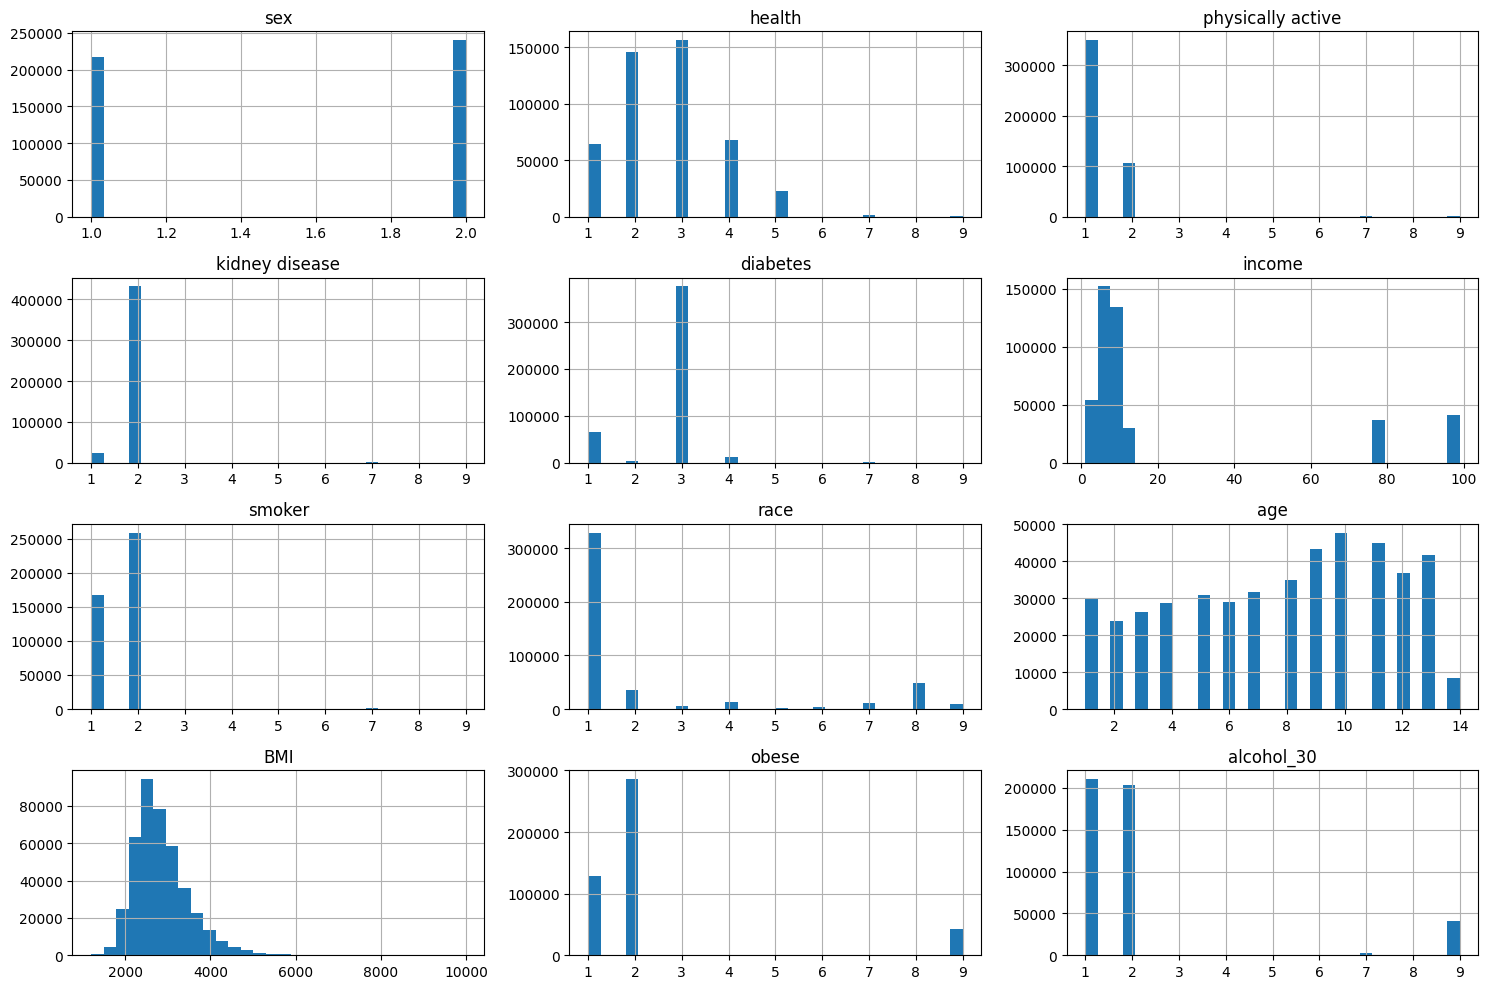

In [127]:
df[new_columns].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

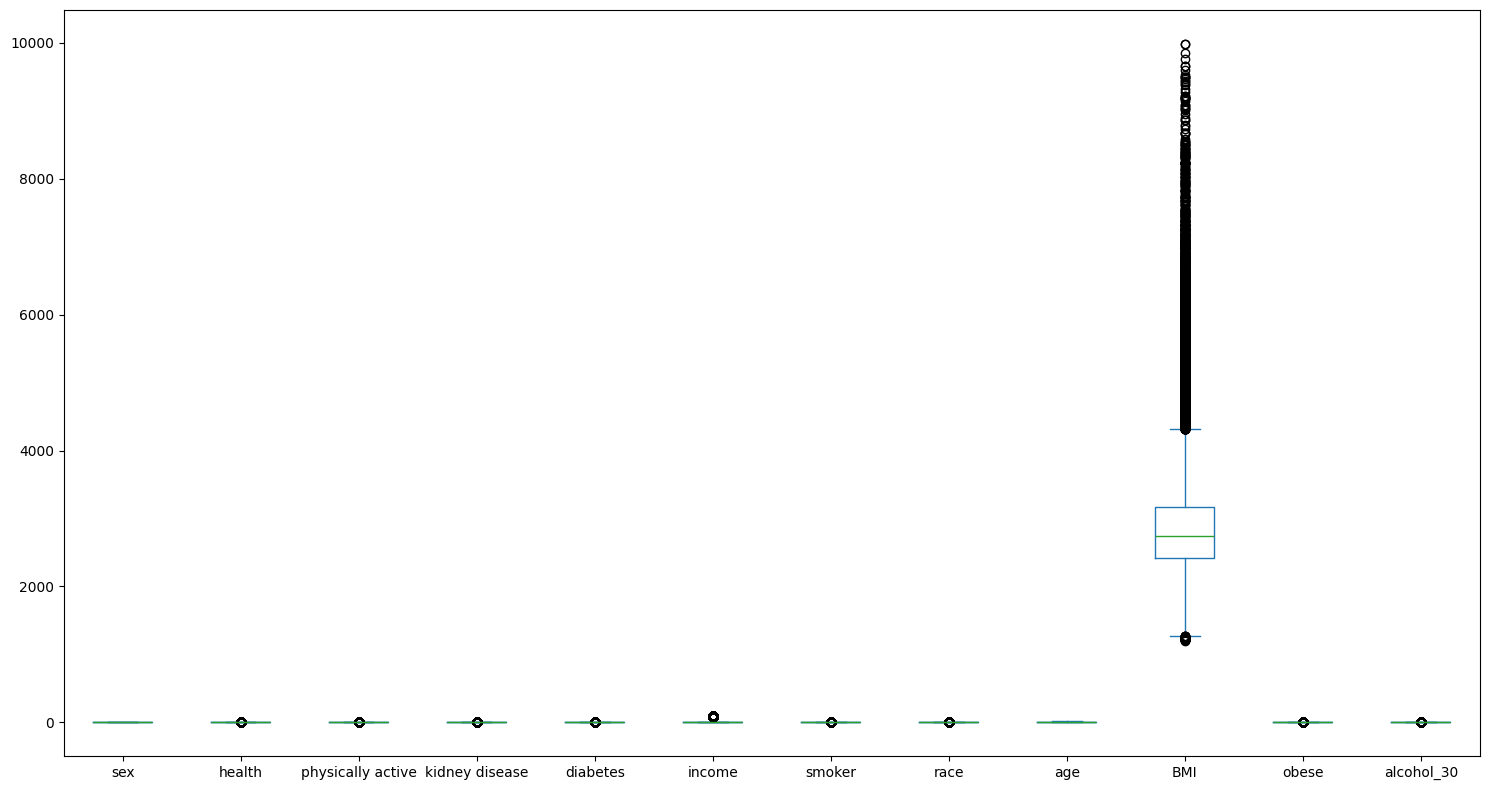

In [128]:
df[new_columns].plot(kind="box", figsize=(15, 8))
plt.tight_layout()
plt.show()

In [129]:
#working with NHANES dataset
demographics = pd.read_csv("demographics.csv")
a1c = pd.read_csv("glycohemoglobin.csv")
bp = pd.read_csv("bloodpressure.csv")
bmi = pd.read_csv("BMI.csv")
chol = pd.read_csv("cholesterol.csv")
diabetes = pd.read_csv("diabetes.csv")
diet = pd.read_csv("dietbehavior.csv")
insulin = pd.read_csv("insulin.csv")
kidney = pd.read_csv("kidneyconditions.csv")
med = pd.read_csv("medicalconditions.csv")
active = pd.read_csv("physactivity.csv")
youth = pd.read_csv("physactivityyouth.csv")
smoker = pd.read_csv("smoking.csv")
obese = pd.read_csv("weighthistory.csv")
glucose = pd.read_csv("glucose.csv")

In [130]:
#merging all datasets using SEQN column
dataset = [demographics, a1c, bp, bmi, chol, diabetes, diet, insulin, kidney, med, active, youth, smoker, obese, glucose]
nhanes = dataset[0]
for i in dataset[1:]:
    nhanes = nhanes.merge(i, on="SEQN", how="left")

In [131]:
nhanes.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,SMD650,SMD100MN,SMQ621,SMD630,SMAQUEX2,WHD010,WHD020,WHD050,WHQ070,LBXGLU
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,1.0,71.0,190.0,200.0,1.0,113.0
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,1.0,70.0,220.0,220.0,2.0,99.0
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,1.0,60.0,150.0,165.0,1.0,156.0
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
useful_cols = ["SEQN", "DIQ010", "RIAGENDR", "KIQ022", "KIQ025",
               "PAD680", "PAD790Q", "PAQ706", "PAQ711",
               "MCQ500", "MCQ160E", "MCQ170M", "SMQ040", "SMD650",
               "WHD020", "BMXBMI", "BPXODI1", "BPXOSY1", 
               "LBXTC", "LBXGH", "LBXGLU"]
nhanes = nhanes[useful_cols]

In [133]:
nhanes.head()

,SEQN,DIQ010,RIAGENDR,KIQ022,KIQ025,PAD680,PAD790Q,PAQ706,PAQ711,MCQ500,...,MCQ170M,SMQ040,SMD650,WHD020,BMXBMI,BPXODI1,BPXOSY1,LBXTC,LBXGH,LBXGLU
0,130378.0,2.0,1.0,2.0,NaN,360.0,3.0,NaN,NaN,NaN,...,NaN,3.0,NaN,190.0,27.0,98.0,135.0,264.0,5.6,113.0
1,130379.0,2.0,1.0,2.0,NaN,480.0,4.0,NaN,NaN,NaN,...,NaN,3.0,NaN,220.0,33.5,84.0,121.0,214.0,5.6,99.0
2,130380.0,1.0,2.0,2.0,NaN,240.0,1.0,NaN,NaN,NaN,...,2.0,NaN,NaN,150.0,29.7,79.0,111.0,187.0,6.2,156.0
3,130381.0,2.0,2.0,NaN,NaN,NaN,NaN,7.0,3.0,NaN,...,NaN,NaN,NaN,NaN,23.8,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,1.0,NaN,NaN,NaN,NaN,7.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [134]:
nhanes.columns = ["SEQN", "HAVE DIABETES", "GENDER", "KIDNEY FAILURE", 
                  "DIALYSIS", "SEDENTARY MINS", "FREQUENCY MODERATE ACTIVITY",
                  "YOUTH: DAYS ACTIVE", "YOUTH: SEDENTARY MINS", "LIVER FAILURE",
                  "HEART ATTACK", "THYROID PROBLEM", "SMOKER", 
                  "CIGARETTES PER DAY", "WEIGHT", "BMI", "BP DIALOSTIC", 
                  "BP SYSTOLIC", "CHOLESTEROL", "A1C", "GLUCOSE"]

In [135]:
nhanes.head()

,SEQN,HAVE DIABETES,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,...,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
0,130378.0,2.0,1.0,2.0,NaN,360.0,3.0,NaN,NaN,NaN,...,NaN,3.0,NaN,190.0,27.0,98.0,135.0,264.0,5.6,113.0
1,130379.0,2.0,1.0,2.0,NaN,480.0,4.0,NaN,NaN,NaN,...,NaN,3.0,NaN,220.0,33.5,84.0,121.0,214.0,5.6,99.0
2,130380.0,1.0,2.0,2.0,NaN,240.0,1.0,NaN,NaN,NaN,...,2.0,NaN,NaN,150.0,29.7,79.0,111.0,187.0,6.2,156.0
3,130381.0,2.0,2.0,NaN,NaN,NaN,NaN,7.0,3.0,NaN,...,NaN,NaN,NaN,NaN,23.8,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,1.0,NaN,NaN,NaN,NaN,7.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [136]:
nhanes.isna().sum()

SEQN                               0
HAVE DIABETES                    193
GENDER                             0
KIDNEY FAILURE                  4126
DIALYSIS                       11612
SEDENTARY MINS                  3795
FREQUENCY MODERATE ACTIVITY     3798
YOUTH: DAYS ACTIVE              8892
YOUTH: SEDENTARY MINS           8892
LIVER FAILURE                  10355
HEART ATTACK                    4126
THYROID PROBLEM                10880
SMOKER                          8690
CIGARETTES PER DAY             10748
WEIGHT                          3447
BMI                             3462
BP DIALOSTIC                    4416
BP SYSTOLIC                     4416
CHOLESTEROL                     5043
A1C                             5218
GLUCOSE                         8261
dtype: int64

In [137]:
#check for NaNs
nan_nhanes = nhanes.columns[nhanes.isna().any()].tolist()
print(nan_nhanes)

['HAVE DIABETES', 'KIDNEY FAILURE', 'DIALYSIS', 'SEDENTARY MINS', 'FREQUENCY MODERATE ACTIVITY', 'YOUTH: DAYS ACTIVE', 'YOUTH: SEDENTARY MINS', 'LIVER FAILURE', 'HEART ATTACK', 'THYROID PROBLEM', 'SMOKER', 'CIGARETTES PER DAY', 'WEIGHT', 'BMI', 'BP DIALOSTIC', 'BP SYSTOLIC', 'CHOLESTEROL', 'A1C', 'GLUCOSE']


In [138]:
nhanes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SEQN                         11933 non-null  float64
 1   HAVE DIABETES                11740 non-null  float64
 2   GENDER                       11933 non-null  float64
 3   KIDNEY FAILURE               7807 non-null   float64
 4   DIALYSIS                     321 non-null    float64
 5   SEDENTARY MINS               8138 non-null   float64
 6   FREQUENCY MODERATE ACTIVITY  8135 non-null   float64
 7   YOUTH: DAYS ACTIVE           3041 non-null   float64
 8   YOUTH: SEDENTARY MINS        3041 non-null   float64
 9   LIVER FAILURE                1578 non-null   float64
 10  HEART ATTACK                 7807 non-null   float64
 11  THYROID PROBLEM              1053 non-null   float64
 12  SMOKER                       3243 non-null   float64
 13  CIGARETTES PER D

In [139]:
#checking all for zero's
nhanes.eq(0).sum()

SEQN                           0
HAVE DIABETES                  0
GENDER                         0
KIDNEY FAILURE                 0
DIALYSIS                       0
SEDENTARY MINS                 0
FREQUENCY MODERATE ACTIVITY    0
YOUTH: DAYS ACTIVE             0
YOUTH: SEDENTARY MINS          0
LIVER FAILURE                  0
HEART ATTACK                   0
THYROID PROBLEM                0
SMOKER                         0
CIGARETTES PER DAY             0
WEIGHT                         0
BMI                            0
BP DIALOSTIC                   0
BP SYSTOLIC                    0
CHOLESTEROL                    0
A1C                            0
GLUCOSE                        0
dtype: int64

In [140]:
#check for blank labels or mislabels
check_cells = [" ", "", "N/A", "missing", "Missing", "NA", 
               "unknown", "Unknown"]
nhanes.isin(check_cells).sum()

SEQN                           0
HAVE DIABETES                  0
GENDER                         0
KIDNEY FAILURE                 0
DIALYSIS                       0
SEDENTARY MINS                 0
FREQUENCY MODERATE ACTIVITY    0
YOUTH: DAYS ACTIVE             0
YOUTH: SEDENTARY MINS          0
LIVER FAILURE                  0
HEART ATTACK                   0
THYROID PROBLEM                0
SMOKER                         0
CIGARETTES PER DAY             0
WEIGHT                         0
BMI                            0
BP DIALOSTIC                   0
BP SYSTOLIC                    0
CHOLESTEROL                    0
A1C                            0
GLUCOSE                        0
dtype: int64

In [141]:
#Comparing statistics for analysis
nhanes.describe()

,SEQN,HAVE DIABETES,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,...,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
count,11933.000000,11740.000000,11933.000000,7807.000000,321.000000,8.138000e+03,8.135000e+03,3.041000e+03,3.041000e+03,1578.000000,...,1053.000000,3243.000000,1185.000000,8486.000000,8471.000000,7517.000000,7517.000000,6890.000000,6715.000000,3672.000000
mean,136344.000000,1.934497,1.532808,1.970539,1.928349,4.469827e+02,6.014247e+01,5.312397e+00,3.451825e+00,1.994930,...,1.364672,2.339500,18.998312,317.142588,27.246665,72.748038,119.288546,181.541074,5.709471,107.884532
std,3444.904716,0.358726,0.498943,0.349082,0.258312,9.174642e+02,7.417083e+02,6.102179e+00,7.101223e+00,0.201389,...,1.206748,0.900889,86.343555,1120.476550,8.137781,11.895572,18.561052,42.316140,1.054899,32.476268
min,130378.000000,1.000000,1.000000,1.000000,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000,...,1.000000,1.000000,1.000000,63.000000,11.100000,33.000000,61.000000,62.000000,3.200000,59.000000
25%,133361.000000,2.000000,1.000000,2.000000,2.000000,1.800000e+02,1.000000e+00,4.000000e+00,1.000000e+00,2.000000,...,1.000000,1.000000,5.000000,145.000000,21.600000,64.000000,106.000000,151.000000,5.200000,93.000000
50%,136344.000000,2.000000,2.000000,2.000000,2.000000,3.000000e+02,2.000000e+00,5.000000e+00,2.000000e+00,2.000000,...,1.000000,3.000000,10.000000,174.000000,26.400000,72.000000,117.000000,178.000000,5.500000,100.000000
75%,139327.000000,2.000000,2.000000,2.000000,2.000000,4.800000e+02,4.000000e+00,7.000000e+00,4.000000e+00,2.000000,...,1.000000,3.000000,20.000000,207.000000,31.700000,80.000000,130.000000,207.000000,5.800000,109.000000
max,142310.000000,9.000000,2.000000,9.000000,2.000000,9.999000e+03,9.999000e+03,9.900000e+01,9.900000e+01,9.000000,...,9.000000,3.000000,999.000000,9999.000000,74.800000,142.000000,232.000000,438.000000,17.100000,561.000000


In [142]:
for i in nhanes.columns:
    print(i, "mean:", nhanes[i].mean(), "std:", nhanes[i].std())

SEQN mean: 136344.0 std: 3444.90471566341
HAVE DIABETES mean: 1.9344974446337309 std: 0.35872635994915847
GENDER mean: 1.5328081789994135 std: 0.49894336877364037
KIDNEY FAILURE mean: 1.9705392596387856 std: 0.3490817407300323
DIALYSIS mean: 1.928348909657321 std: 0.2583119778129151
SEDENTARY MINS mean: 446.9826738756451 std: 917.4641531049826
FREQUENCY MODERATE ACTIVITY mean: 60.14247080516288 std: 741.7083365037673
YOUTH: DAYS ACTIVE mean: 5.31239723775074 std: 6.102178823135117
YOUTH: SEDENTARY MINS mean: 3.4518250575468596 std: 7.101222846206866
LIVER FAILURE mean: 1.9949302915082383 std: 0.20138934414236967
HEART ATTACK mean: 1.9691302677084668 std: 0.35097324414224673
THYROID PROBLEM mean: 1.3646723646723646 std: 1.2067482198566517
SMOKER mean: 2.3395004625346902 std: 0.9008889281210051
CIGARETTES PER DAY mean: 18.99831223628692 std: 86.34355480641567
WEIGHT mean: 317.14258779165687 std: 1120.4765501370587
BMI mean: 27.246665092669108 std: 8.137780644865733
BP DIALOSTIC mean: 72.

In [143]:
# columns need correcting
# weight, cigarettes per day, sedentary mins, frequency moderate activity,
# youth days active, youth sedentary, 

In [144]:
for i in nhanes.columns:
    print(i, "min:", nhanes[i].min(), "max:", nhanes[i].max())

SEQN min: 130378.0 max: 142310.0
HAVE DIABETES min: 1.0 max: 9.0
GENDER min: 1.0 max: 2.0
KIDNEY FAILURE min: 1.0 max: 9.0
DIALYSIS min: 1.0 max: 2.0
SEDENTARY MINS min: 5.397605346934028e-79 max: 9999.0
FREQUENCY MODERATE ACTIVITY min: 5.397605346934028e-79 max: 9999.0
YOUTH: DAYS ACTIVE min: 5.397605346934028e-79 max: 99.0
YOUTH: SEDENTARY MINS min: 5.397605346934028e-79 max: 99.0
LIVER FAILURE min: 1.0 max: 9.0
HEART ATTACK min: 1.0 max: 9.0
THYROID PROBLEM min: 1.0 max: 9.0
SMOKER min: 1.0 max: 3.0
CIGARETTES PER DAY min: 1.0 max: 999.0
WEIGHT min: 63.0 max: 9999.0
BMI min: 11.1 max: 74.8
BP DIALOSTIC min: 33.0 max: 142.0
BP SYSTOLIC min: 61.0 max: 232.0
CHOLESTEROL min: 62.0 max: 438.0
A1C min: 3.2 max: 17.1
GLUCOSE min: 59.0 max: 561.0


In [145]:
#same columns need to be rounded weight is too high

In [146]:
for i in nhanes.columns:
    print(i, "mean:", nhanes[i].mean(), "median:", nhanes[i].median())

SEQN mean: 136344.0 median: 136344.0
HAVE DIABETES mean: 1.9344974446337309 median: 2.0
GENDER mean: 1.5328081789994135 median: 2.0
KIDNEY FAILURE mean: 1.9705392596387856 median: 2.0
DIALYSIS mean: 1.928348909657321 median: 2.0
SEDENTARY MINS mean: 446.9826738756451 median: 300.0
FREQUENCY MODERATE ACTIVITY mean: 60.14247080516288 median: 2.0
YOUTH: DAYS ACTIVE mean: 5.31239723775074 median: 5.0
YOUTH: SEDENTARY MINS mean: 3.4518250575468596 median: 2.0
LIVER FAILURE mean: 1.9949302915082383 median: 2.0
HEART ATTACK mean: 1.9691302677084668 median: 2.0
THYROID PROBLEM mean: 1.3646723646723646 median: 1.0
SMOKER mean: 2.3395004625346902 median: 3.0
CIGARETTES PER DAY mean: 18.99831223628692 median: 10.0
WEIGHT mean: 317.14258779165687 median: 174.0
BMI mean: 27.246665092669108 median: 26.4
BP DIALOSTIC mean: 72.74803778102967 median: 72.0
BP SYSTOLIC mean: 119.28854596248503 median: 117.0
CHOLESTEROL mean: 181.54107402031931 median: 178.0
A1C mean: 5.709471332836932 median: 5.5
GLUCOSE

In [147]:
for i in nhanes.columns:
    print(i, "std:", nhanes[i].std(), "25:", nhanes[i].quantile(0.25), 
          "75:", nhanes[i].quantile(0.75))

SEQN std: 3444.90471566341 25: 133361.0 75: 139327.0
HAVE DIABETES std: 0.35872635994915847 25: 2.0 75: 2.0
GENDER std: 0.49894336877364037 25: 1.0 75: 2.0
KIDNEY FAILURE std: 0.3490817407300323 25: 2.0 75: 2.0
DIALYSIS std: 0.2583119778129151 25: 2.0 75: 2.0
SEDENTARY MINS std: 917.4641531049826 25: 180.0 75: 480.0
FREQUENCY MODERATE ACTIVITY std: 741.7083365037673 25: 1.0 75: 4.0
YOUTH: DAYS ACTIVE std: 6.102178823135117 25: 4.0 75: 7.0
YOUTH: SEDENTARY MINS std: 7.101222846206866 25: 1.0 75: 4.0
LIVER FAILURE std: 0.20138934414236967 25: 2.0 75: 2.0
HEART ATTACK std: 0.35097324414224673 25: 2.0 75: 2.0
THYROID PROBLEM std: 1.2067482198566517 25: 1.0 75: 1.0
SMOKER std: 0.9008889281210051 25: 1.0 75: 3.0
CIGARETTES PER DAY std: 86.34355480641567 25: 5.0 75: 20.0
WEIGHT std: 1120.4765501370587 25: 145.0 75: 207.0
BMI std: 8.137780644865733 25: 21.6 75: 31.7
BP DIALOSTIC std: 11.895571778384957 25: 64.0 75: 80.0
BP SYSTOLIC std: 18.561052201733258 25: 106.0 75: 130.0
CHOLESTEROL std: 4

In [148]:
#Start my clean up remove  999s and any other non helpful values
nhanes["SEDENTARY MINS"].value_counts().get(9999, 0)

67

In [149]:
nhanes["FREQUENCY MODERATE ACTIVITY"].value_counts().get(9999, 0)

39

In [150]:
nhanes["WEIGHT"].value_counts().get(9999, 0)

88

In [151]:
nhanes["YOUTH: DAYS ACTIVE"].value_counts().get(9999, 0)

0

In [152]:
nhanes["YOUTH: SEDENTARY MINS"].value_counts().get(9999, 0)

0

In [153]:
nhanes["CIGARETTES PER DAY"].value_counts().get(9999, 0)

0

In [154]:
nhanes["SEDENTARY MINS"] = nhanes["SEDENTARY MINS"].replace(9999, np.nan)
nhanes["FREQUENCY MODERATE ACTIVITY"] = nhanes["FREQUENCY MODERATE ACTIVITY"].replace(9999, np.nan)
nhanes["WEIGHT"] = nhanes["WEIGHT"].replace(9999, np.nan)

In [155]:
nhanes["SEDENTARY MINS"].value_counts().get(9999, 0)

0

In [156]:
nhanes["FREQUENCY MODERATE ACTIVITY"].value_counts().get(9999, 0)

0

In [157]:
nhanes["WEIGHT"].value_counts().get(9999, 0)

0

In [158]:
#replace impossible values
nhanes["WEIGHT"] = nhanes["WEIGHT"].mask(nhanes["WEIGHT"] > 700, np.nan)
nhanes["SEDENTARY MINS"] = nhanes["SEDENTARY MINS"].mask(nhanes["SEDENTARY MINS"] > 1380, np.nan)
nhanes["FREQUENCY MODERATE ACTIVITY"] = nhanes["FREQUENCY MODERATE ACTIVITY"].mask(
    nhanes["FREQUENCY MODERATE ACTIVITY"] > 180, np.nan)
nhanes["YOUTH: SEDENTARY MINS"] = nhanes["YOUTH: SEDENTARY MINS"].mask(
    nhanes["YOUTH: SEDENTARY MINS"] > 9, np.nan)
nhanes["YOUTH: DAYS ACTIVE"] = nhanes["YOUTH: DAYS ACTIVE"].mask(nhanes["YOUTH: DAYS ACTIVE"] > 7, np.nan)
nhanes["CIGARETTES PER DAY"] = nhanes["CIGARETTES PER DAY"].mask(
    nhanes["CIGARETTES PER DAY"] > 90, np.nan)

In [159]:
nhanes["YOUTH: SEDENTARY MINS"] = nhanes["YOUTH: SEDENTARY MINS"].mask(
    nhanes["YOUTH: SEDENTARY MINS"].abs()<1e-50, np.nan)
nhanes["YOUTH: DAYS ACTIVE"] = nhanes["YOUTH: DAYS ACTIVE"].mask(
    nhanes["YOUTH: DAYS ACTIVE"].abs()<1e-50, np.nan)
nhanes["FREQUENCY MODERATE ACTIVITY"] = nhanes["FREQUENCY MODERATE ACTIVITY"].mask(
    nhanes["FREQUENCY MODERATE ACTIVITY"].abs()<1e-50, np.nan)
nhanes["SEDENTARY MINS"] = nhanes["SEDENTARY MINS"].mask(
    nhanes["SEDENTARY MINS"].abs()<1e-50, np.nan)

In [160]:
nhanes.head()

,SEQN,HAVE DIABETES,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,...,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
0,130378.0,2.0,1.0,2.0,NaN,360.0,3.0,NaN,NaN,NaN,...,NaN,3.0,NaN,190.0,27.0,98.0,135.0,264.0,5.6,113.0
1,130379.0,2.0,1.0,2.0,NaN,480.0,4.0,NaN,NaN,NaN,...,NaN,3.0,NaN,220.0,33.5,84.0,121.0,214.0,5.6,99.0
2,130380.0,1.0,2.0,2.0,NaN,240.0,1.0,NaN,NaN,NaN,...,2.0,NaN,NaN,150.0,29.7,79.0,111.0,187.0,6.2,156.0
3,130381.0,2.0,2.0,NaN,NaN,NaN,NaN,7.0,3.0,NaN,...,NaN,NaN,NaN,NaN,23.8,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,1.0,NaN,NaN,NaN,NaN,7.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
#Rechecking after cleaning 
nhanes.describe()

,SEQN,HAVE DIABETES,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,...,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
count,11933.000000,11740.000000,11933.000000,7807.000000,321.000000,8057.000000,6390.000000,2825.000000,2896.000000,1578.000000,...,1053.000000,3243.000000,1174.000000,8358.000000,8471.000000,7517.000000,7517.000000,6890.000000,6715.000000,3672.000000
mean,136344.000000,1.934497,1.532808,1.970539,1.928349,362.535683,3.369014,5.313628,3.092887,1.994930,...,1.364672,2.339500,11.356048,179.502273,27.246665,72.748038,119.288546,181.541074,5.709471,107.884532
std,3444.904716,0.358726,0.498943,0.349082,0.258312,209.820574,3.604919,1.823490,2.099265,0.201389,...,1.206748,0.900889,9.380612,48.115718,8.137781,11.895572,18.561052,42.316140,1.054899,32.476268
min,130378.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,63.000000,11.100000,33.000000,61.000000,62.000000,3.200000,59.000000
25%,133361.000000,2.000000,1.000000,2.000000,2.000000,180.000000,2.000000,4.000000,2.000000,2.000000,...,1.000000,1.000000,5.000000,145.000000,21.600000,64.000000,106.000000,151.000000,5.200000,93.000000
50%,136344.000000,2.000000,2.000000,2.000000,2.000000,300.000000,3.000000,6.000000,2.000000,2.000000,...,1.000000,3.000000,10.000000,173.000000,26.400000,72.000000,117.000000,178.000000,5.500000,100.000000
75%,139327.000000,2.000000,2.000000,2.000000,2.000000,480.000000,4.000000,7.000000,4.000000,2.000000,...,1.000000,3.000000,18.000000,205.000000,31.700000,80.000000,130.000000,207.000000,5.800000,109.000000
max,142310.000000,9.000000,2.000000,9.000000,2.000000,1380.000000,180.000000,7.000000,9.000000,9.000000,...,9.000000,3.000000,90.000000,530.000000,74.800000,142.000000,232.000000,438.000000,17.100000,561.000000


In [162]:
for i in nhanes.columns:
    print(i, "mean:", nhanes[i].mean(), "std:", nhanes[i].std())

SEQN mean: 136344.0 std: 3444.90471566341
HAVE DIABETES mean: 1.9344974446337309 std: 0.35872635994915847
GENDER mean: 1.5328081789994135 std: 0.49894336877364037
KIDNEY FAILURE mean: 1.9705392596387856 std: 0.3490817407300323
DIALYSIS mean: 1.928348909657321 std: 0.2583119778129151
SEDENTARY MINS mean: 362.5356832567953 std: 209.82057402905414
FREQUENCY MODERATE ACTIVITY mean: 3.369014084507042 std: 3.6049188320086407
YOUTH: DAYS ACTIVE mean: 5.313628318584071 std: 1.8234898394740773
YOUTH: SEDENTARY MINS mean: 3.0928867403314917 std: 2.0992648986321276
LIVER FAILURE mean: 1.9949302915082383 std: 0.20138934414236967
HEART ATTACK mean: 1.9691302677084668 std: 0.35097324414224673
THYROID PROBLEM mean: 1.3646723646723646 std: 1.2067482198566517
SMOKER mean: 2.3395004625346902 std: 0.9008889281210051
CIGARETTES PER DAY mean: 11.356047700170357 std: 9.380612139421112
WEIGHT mean: 179.5022732711175 std: 48.115718298186785
BMI mean: 27.246665092669108 std: 8.137780644865733
BP DIALOSTIC mean

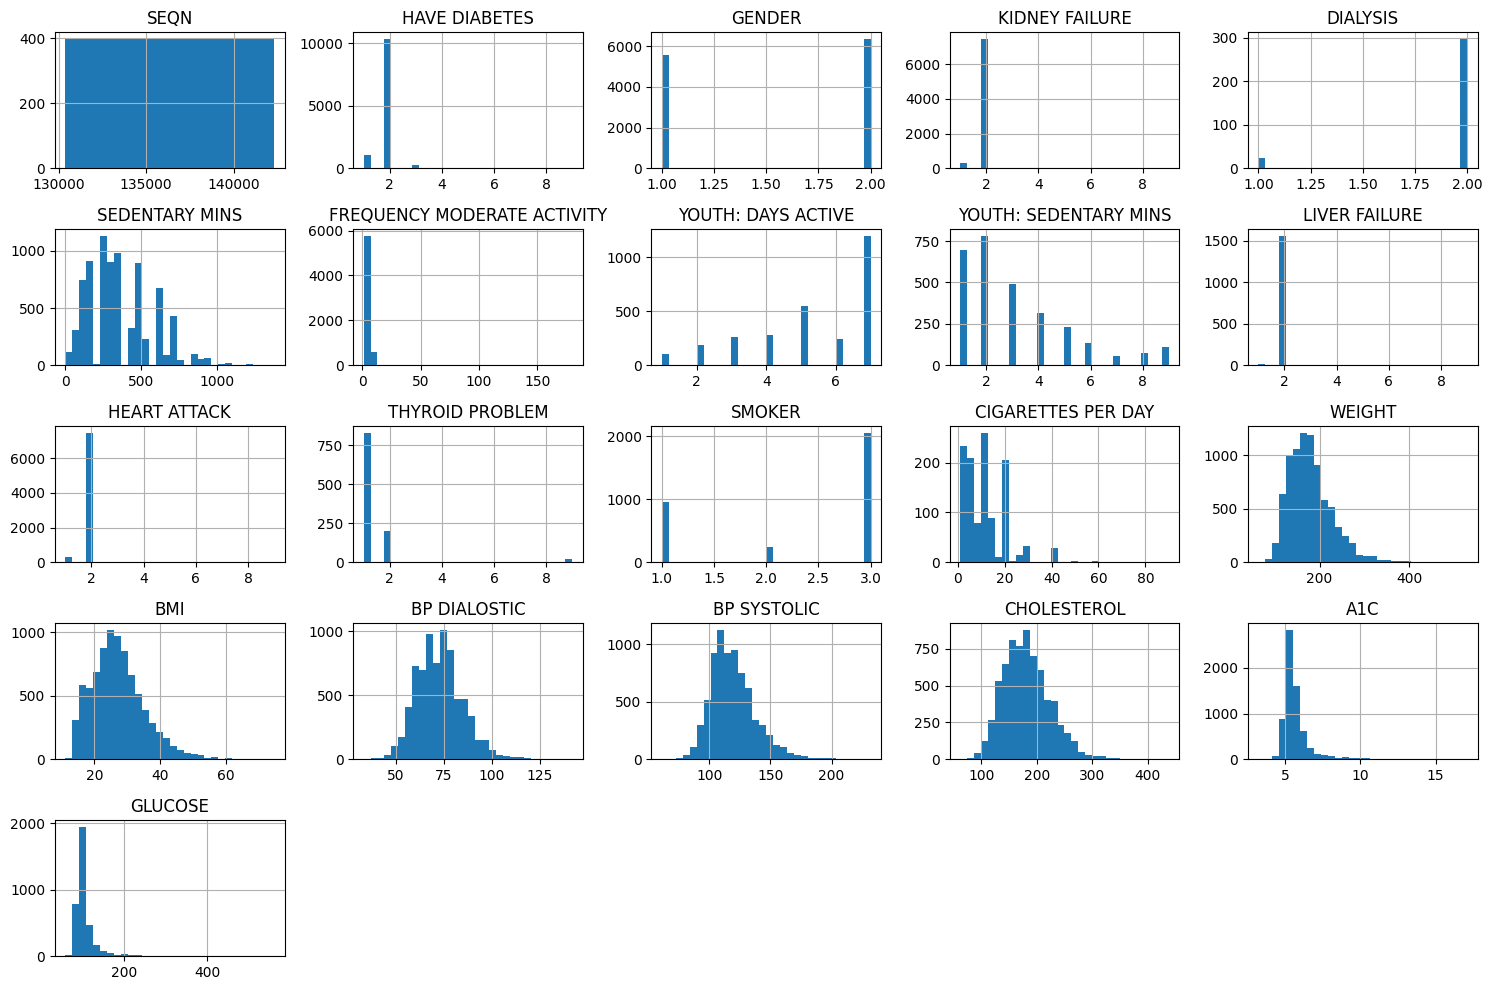

In [163]:
#columns are clean std less than mean okay to move forward
#Time to impute Visual plotting for statistics
nhanes.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

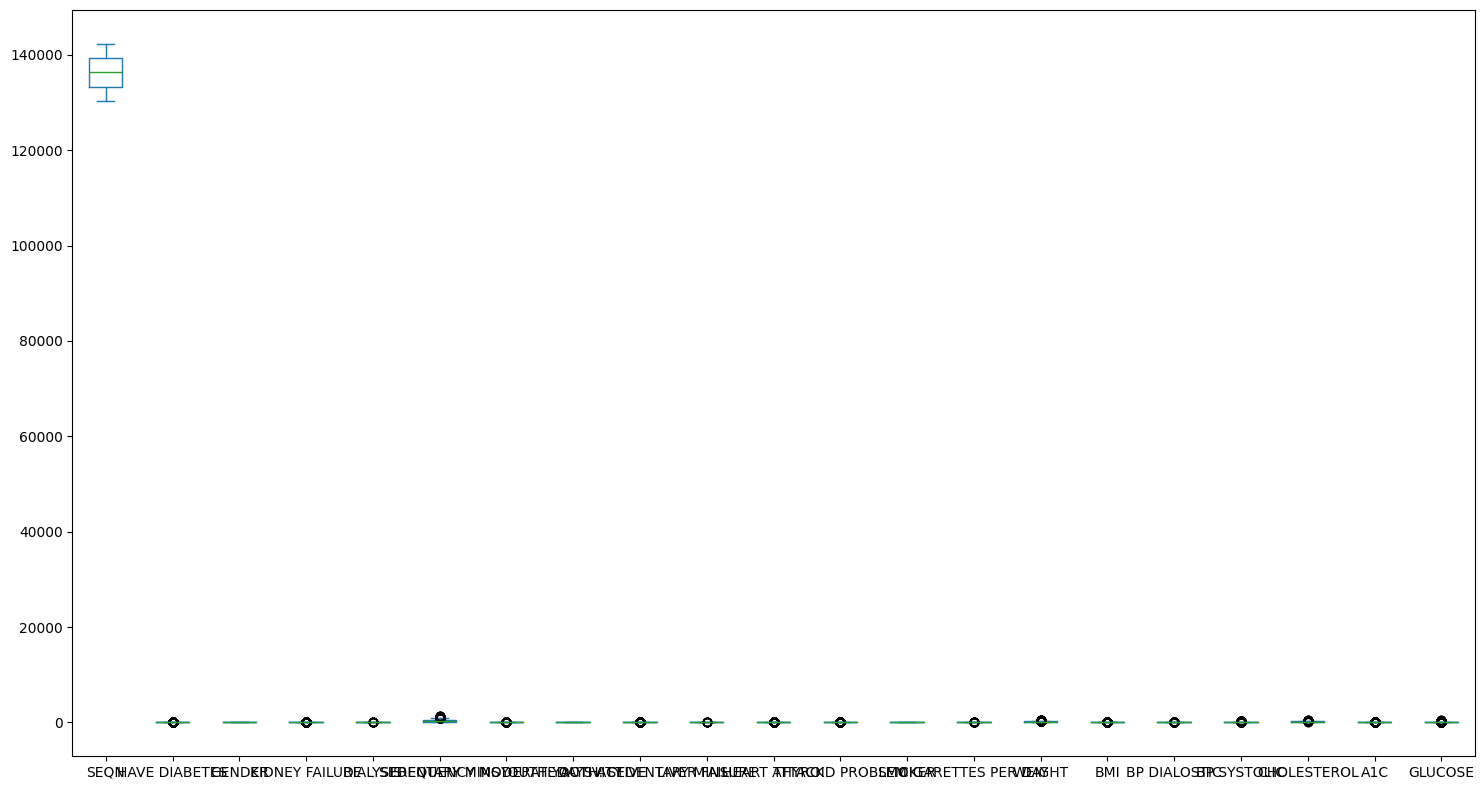

In [164]:
nhanes.plot(kind="box", figsize=(15, 8))
plt.tight_layout()
plt.show()

In [165]:
#I have categoricals and numericals. mode for categoricals
#all numericals are skewed median is best 
nhanes_original = nhanes.copy()

In [166]:
#Nearing split must clean up target column first
#drop rows with missing values
nhanes["HAVE DIABETES"] = (
    nhanes["HAVE DIABETES"].replace(9, np.nan))

#drop rows with missing values
nhanes["HAVE DIABETES"] = (
    nhanes["HAVE DIABETES"].replace(7, np.nan))

nhanes = nhanes.dropna(subset=["HAVE DIABETES"])

In [167]:
#Check Have Diabetes column (target column)
nhanes["HAVE DIABETES"].isna().sum()

0

In [168]:
diabetes = {1: "Diabetes", 2: "No Diabetes", 3: "Borderline"}
nhanes["HAVE DIABETES"] = nhanes["HAVE DIABETES"].replace(diabetes)

C:\Users\fayed\AppData\Local\Temp\ipykernel_9048\1604872043.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nhanes["HAVE DIABETES"] = nhanes["HAVE DIABETES"].replace(diabetes)


In [169]:
# Check Nan's were dropped
# pd.set_option("display.max_rows", None)
# print(nhanes["HAVE DIABETES"])

In [170]:
nhanes.head()

,SEQN,HAVE DIABETES,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,...,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
0,130378.0,No Diabetes,1.0,2.0,NaN,360.0,3.0,NaN,NaN,NaN,...,NaN,3.0,NaN,190.0,27.0,98.0,135.0,264.0,5.6,113.0
1,130379.0,No Diabetes,1.0,2.0,NaN,480.0,4.0,NaN,NaN,NaN,...,NaN,3.0,NaN,220.0,33.5,84.0,121.0,214.0,5.6,99.0
2,130380.0,Diabetes,2.0,2.0,NaN,240.0,1.0,NaN,NaN,NaN,...,2.0,NaN,NaN,150.0,29.7,79.0,111.0,187.0,6.2,156.0
3,130381.0,No Diabetes,2.0,NaN,NaN,NaN,NaN,7.0,3.0,NaN,...,NaN,NaN,NaN,NaN,23.8,NaN,NaN,NaN,NaN,NaN
4,130382.0,No Diabetes,1.0,NaN,NaN,NaN,NaN,7.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [171]:
#Drop the SEQN column
nhanes = nhanes.drop("SEQN", axis=1)

In [172]:
nhanes.head()

,HAVE DIABETES,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,HEART ATTACK,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
0,No Diabetes,1.0,2.0,NaN,360.0,3.0,NaN,NaN,NaN,2.0,NaN,3.0,NaN,190.0,27.0,98.0,135.0,264.0,5.6,113.0
1,No Diabetes,1.0,2.0,NaN,480.0,4.0,NaN,NaN,NaN,2.0,NaN,3.0,NaN,220.0,33.5,84.0,121.0,214.0,5.6,99.0
2,Diabetes,2.0,2.0,NaN,240.0,1.0,NaN,NaN,NaN,2.0,2.0,NaN,NaN,150.0,29.7,79.0,111.0,187.0,6.2,156.0
3,No Diabetes,2.0,NaN,NaN,NaN,NaN,7.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,23.8,NaN,NaN,NaN,NaN,NaN
4,No Diabetes,1.0,NaN,NaN,NaN,NaN,7.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [173]:
#Split train and test data
X = nhanes.drop(columns=["HAVE DIABETES"])
y = nhanes["HAVE DIABETES"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42)

In [174]:
X_train.head()

,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,HEART ATTACK,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
9666,2.0,2.0,NaN,60.0,1.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,38.0,88.0,141.0,142.0,6.7,NaN
10371,2.0,2.0,NaN,240.0,5.0,NaN,NaN,NaN,2.0,1.0,NaN,NaN,147.0,29.0,67.0,129.0,208.0,5.9,NaN
9128,2.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,14.9,NaN,NaN,NaN,NaN,NaN
8881,2.0,2.0,NaN,300.0,3.0,NaN,NaN,NaN,2.0,NaN,3.0,NaN,175.0,32.0,82.0,112.0,172.0,4.9,109.0
2517,1.0,2.0,NaN,240.0,2.0,NaN,NaN,NaN,2.0,NaN,3.0,NaN,170.0,28.7,81.0,136.0,207.0,5.9,112.0


In [175]:
y_train.head()

9666        Diabetes
10371    No Diabetes
9128     No Diabetes
8881     No Diabetes
2517     No Diabetes
Name: HAVE DIABETES, dtype: object

In [176]:
#Split training and validation data
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, shuffle=True, random_state=42)

In [177]:
X_val.head()

,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,HEART ATTACK,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
6244,2.0,2.0,NaN,480.0,3.0,NaN,NaN,NaN,2.0,NaN,1.0,1.0,182.0,NaN,NaN,NaN,NaN,NaN,NaN
158,2.0,NaN,NaN,NaN,NaN,7.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,15.2,59.0,99.0,175.0,NaN,NaN
2682,1.0,2.0,NaN,480.0,4.0,NaN,NaN,NaN,2.0,NaN,3.0,NaN,220.0,30.2,87.0,133.0,235.0,5.4,NaN
8175,2.0,NaN,NaN,NaN,NaN,5.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,56.0,106.0,142.0,NaN,NaN
5444,1.0,2.0,NaN,660.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,294.0,41.0,90.0,113.0,250.0,5.4,105.0


In [178]:
y_val.head()

6244    No Diabetes
158     No Diabetes
2682    No Diabetes
8175    No Diabetes
5444    No Diabetes
Name: HAVE DIABETES, dtype: object

In [179]:
#doublecheck the columns for othere reponses
mycolumns = ["KIDNEY FAILURE", "DIALYSIS", "SEDENTARY MINS", "FREQUENCY MODERATE ACTIVITY",
                  "YOUTH: DAYS ACTIVE", "YOUTH: SEDENTARY MINS", "LIVER FAILURE",
                  "HEART ATTACK", "THYROID PROBLEM", "SMOKER", 
                  "CIGARETTES PER DAY", "WEIGHT"]

In [180]:
nuisance = [7, 77, 777, 7777, 9, 99, 999]

for col in mycolumns:
    print(col, "→", X_train[col].isin(nuisance).sum())
    print(col, "→", X_val[col].isin(nuisance).sum())
    print(col, "→", X_test[col].isin(nuisance).sum())

KIDNEY FAILURE → 8
KIDNEY FAILURE → 4
KIDNEY FAILURE → 1
DIALYSIS → 0
DIALYSIS → 0
DIALYSIS → 0
SEDENTARY MINS → 2
SEDENTARY MINS → 0
SEDENTARY MINS → 0
FREQUENCY MODERATE ACTIVITY → 316
FREQUENCY MODERATE ACTIVITY → 111
FREQUENCY MODERATE ACTIVITY → 97
YOUTH: DAYS ACTIVE → 716
YOUTH: DAYS ACTIVE → 226
YOUTH: DAYS ACTIVE → 258
YOUTH: SEDENTARY MINS → 112
YOUTH: SEDENTARY MINS → 27
YOUTH: SEDENTARY MINS → 30
LIVER FAILURE → 1
LIVER FAILURE → 0
LIVER FAILURE → 0
HEART ATTACK → 6
HEART ATTACK → 4
HEART ATTACK → 3
THYROID PROBLEM → 12
THYROID PROBLEM → 8
THYROID PROBLEM → 3
SMOKER → 0
SMOKER → 0
SMOKER → 0
CIGARETTES PER DAY → 23
CIGARETTES PER DAY → 17
CIGARETTES PER DAY → 9
WEIGHT → 2
WEIGHT → 1
WEIGHT → 3


In [181]:
X_train[mycolumns] = X_train[mycolumns].replace(nuisance, np.nan)
X_val[mycolumns]   = X_val[mycolumns].replace(nuisance, np.nan)
X_test[mycolumns]  = X_test[mycolumns].replace(nuisance, np.nan)

In [182]:
#recheck
nuisance = [7, 77, 777, 7777, 9, 99, 999]

for col in mycolumns:
    print(col, "→", X_train[col].isin(nuisance).sum())
    print(col, "→", X_val[col].isin(nuisance).sum())
    print(col, "→", X_test[col].isin(nuisance).sum())

KIDNEY FAILURE → 0
KIDNEY FAILURE → 0
KIDNEY FAILURE → 0
DIALYSIS → 0
DIALYSIS → 0
DIALYSIS → 0
SEDENTARY MINS → 0
SEDENTARY MINS → 0
SEDENTARY MINS → 0
FREQUENCY MODERATE ACTIVITY → 0
FREQUENCY MODERATE ACTIVITY → 0
FREQUENCY MODERATE ACTIVITY → 0
YOUTH: DAYS ACTIVE → 0
YOUTH: DAYS ACTIVE → 0
YOUTH: DAYS ACTIVE → 0
YOUTH: SEDENTARY MINS → 0
YOUTH: SEDENTARY MINS → 0
YOUTH: SEDENTARY MINS → 0
LIVER FAILURE → 0
LIVER FAILURE → 0
LIVER FAILURE → 0
HEART ATTACK → 0
HEART ATTACK → 0
HEART ATTACK → 0
THYROID PROBLEM → 0
THYROID PROBLEM → 0
THYROID PROBLEM → 0
SMOKER → 0
SMOKER → 0
SMOKER → 0
CIGARETTES PER DAY → 0
CIGARETTES PER DAY → 0
CIGARETTES PER DAY → 0
WEIGHT → 0
WEIGHT → 0
WEIGHT → 0


In [183]:
#no need to check y I already replaced the 9s and 7s

In [184]:
#need to convert x categoricals to strings
string_columns = {
    "GENDER": {1: "MALE", 2: "FEMALE"},
    "KIDNEY FAILURE": {1: "YES", 2: "NO"}, 
    "DIALYSIS": {1: "YES", 2: "NO"}, 
    "LIVER FAILURE": {1: "YES", 2: "NO"},
    "HEART ATTACK": {1: "YES", 2: "NO"}, 
    "THYROID PROBLEM": {1: "YES", 2: "NO"}, 
    "SMOKER": {1: "EVERYDAY", 2: "SOME DAYS", 3: "NO"}
}

for answer, label in string_columns.items():
    X_train[answer] = X_train[answer].map(label)
    X_val[answer]   = X_val[answer].map(label)
    X_test[answer]  = X_test[answer].map(label)

In [185]:
# fil missing values and get rid of NaNs
categorical_columns = ["GENDER", "KIDNEY FAILURE", "DIALYSIS", "SMOKER",
                  "LIVER FAILURE", "HEART ATTACK", "THYROID PROBLEM"]       

for col in categorical_columns:
    mode_series = X_train[col].mode(dropna=True)

    if mode_series.empty:
        fill_value = "MISSING"
    else:
        fill_value = mode_series.iloc[0]

    X_train[col] = X_train[col].fillna(fill_value)
    X_val[col]   = X_val[col].fillna(fill_value)
    X_test[col]  = X_test[col].fillna(fill_value)

In [186]:
numerical_columns = ["SEDENTARY MINS", "FREQUENCY MODERATE ACTIVITY",
                     "YOUTH: DAYS ACTIVE", "YOUTH: SEDENTARY MINS", 
                     "CIGARETTES PER DAY", "WEIGHT", "BMI", 
                     "BP DIALOSTIC", "BP SYSTOLIC", "CHOLESTEROL",
                     "A1C", "GLUCOSE"]

In [187]:
median_values = X_train[numerical_columns].median()
X_train[numerical_columns] = X_train[numerical_columns].fillna(median_values)
X_val[numerical_columns] = X_val[numerical_columns].fillna(median_values)
X_test[numerical_columns] = X_test[numerical_columns].fillna(median_values)

In [188]:
X_train.head()

,GENDER,KIDNEY FAILURE,DIALYSIS,SEDENTARY MINS,FREQUENCY MODERATE ACTIVITY,YOUTH: DAYS ACTIVE,YOUTH: SEDENTARY MINS,LIVER FAILURE,HEART ATTACK,THYROID PROBLEM,SMOKER,CIGARETTES PER DAY,WEIGHT,BMI,BP DIALOSTIC,BP SYSTOLIC,CHOLESTEROL,A1C,GLUCOSE
6042,FEMALE,NO,NO,300.0,3.0,3.0,3.0,NO,NO,YES,NO,10.0,172.0,26.4,72.0,117.0,178.0,5.5,100.0
6041,FEMALE,NO,NO,420.0,1.0,4.0,2.0,NO,NO,YES,NO,10.0,140.0,34.5,67.0,106.0,178.0,5.5,100.0
3544,MALE,NO,NO,300.0,3.0,4.0,4.0,NO,NO,YES,NO,10.0,172.0,24.1,60.0,107.0,151.0,5.5,100.0
3193,MALE,YES,NO,960.0,3.0,4.0,2.0,NO,YES,YES,NO,10.0,192.0,26.4,71.0,166.0,98.0,6.1,100.0
3673,FEMALE,NO,NO,480.0,1.0,4.0,2.0,NO,NO,YES,NO,10.0,180.0,35.1,68.0,93.0,172.0,5.3,100.0


In [189]:
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)   # strings → ints
y_val_int   = le.transform(y_val)
y_test_int  = le.transform(y_test)

In [190]:
#onehot training data
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[categorical_columns])
X_train_ohe = ohe.transform(X_train[categorical_columns])
X_val_ohe   = ohe.transform(X_val[categorical_columns])
X_test_ohe  = ohe.transform(X_test[categorical_columns])

In [191]:
print(type(X_train_ohe))
print(X_train_ohe.dtype)

<class 'numpy.ndarray'>
float64


In [192]:
#onehot testing data
encode = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encode.fit(y_train.to_numpy().reshape(-1, 1))
y_train_ohe = encode.transform(y_train.to_numpy().reshape(-1,1))
y_val_ohe   = encode.transform(y_val.to_numpy().reshape(-1,1))
y_test_ohe  = encode.transform(y_test.to_numpy().reshape(-1,1))

In [193]:
print(type(y_train_ohe))
print(y_train_ohe.dtype)

<class 'numpy.ndarray'>
float64


In [194]:
#normalize training data
scaler = RobustScaler()
scaler.fit(X_train[numerical_columns])
X_train_scaled = scaler.transform(X_train[numerical_columns])
X_val_scaled = scaler.transform(X_val[numerical_columns])
X_test_scaled = scaler.transform(X_test[numerical_columns])

In [195]:
print(type(X_train_scaled))
print(X_train_scaled.dtype)

<class 'numpy.ndarray'>
float64


In [196]:
X_train_scaled, X_val_scaled, X_test_scaled

(array([[  0.    ,   0.    ,  -1.    , ...,   0.    ,   0.    ,   0.    ],
        [  1.    ,  -2.    ,   0.    , ...,   0.    ,   0.    ,   0.    ],
        [  0.    ,   0.    ,   0.    , ...,  -1.6875,   0.    ,   0.    ],
        ...,
        [  1.5   ,   0.    ,   0.    , ...,   0.1875, -11.    , -22.    ],
        [  0.    ,   0.    ,   0.    , ...,   0.    ,   0.    ,   0.    ],
        [ -0.5   ,  -1.    ,   0.    , ...,  -1.0625,   0.    ,   0.    ]]),
 array([[ 1.5   ,  0.    ,  0.    , ...,  0.    ,  0.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    , ..., -0.1875,  0.    ,  0.    ],
        [ 1.5   ,  1.    ,  0.    , ...,  3.5625, -1.    ,  0.    ],
        ...,
        [ 0.    ,  0.    ,  0.    , ..., -0.9375,  0.    ,  0.    ],
        [ 3.5   ,  0.    ,  0.    , ...,  0.    ,  4.    ,  0.    ],
        [ 0.    ,  0.    ,  0.    , ...,  2.6875,  2.    ,  0.    ]]),
 array([[  0.    ,   0.    ,   0.    , ...,   0.    ,   0.    ,   0.    ],
        [  1.    ,  -1.    ,   

In [197]:
y_train_ohe, y_val_ohe, y_test_ohe

(array([[0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        ...,
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]]),
 array([[0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        ...,
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]]),
 array([[0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        ...,
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.]]))

In [198]:
print(X_train_scaled.dtype, X_train_ohe.dtype)

float64 float64


In [199]:
#Concatenate everything
X_train_final = np.concatenate([X_train_scaled, X_train_ohe], axis=1)
X_val_final   = np.concatenate([X_val_scaled, X_val_ohe], axis=1)
X_test_final  = np.concatenate([X_test_scaled, X_test_ohe], axis=1)

In [200]:
print(X_train_final.dtype)

float64


In [201]:
print(X_val_final.dtype)

float64


In [202]:
joblib.dump(ohe, "ohe.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [203]:
#Convert all to tensors
X_train_tensor = tf.constant(X_train_final, dtype=tf.float32)
X_val_tensor = tf.constant(X_val_final, dtype=tf.float32)
X_test_tensor = tf.constant(X_test_final, dtype=tf.float32)

y_train_tensor = tf.constant(y_train_ohe, dtype=tf.float32)
y_val_tensor = tf.constant(y_val_ohe, dtype=tf.float32)
y_test_tensor = tf.constant(y_test_ohe, dtype=tf.float32)

In [204]:
print(type(X_val_tensor))
print(X_val_tensor.dtype)

<class 'tensorflow.python.framework.ops.EagerTensor'>
<dtype: 'float32'>


In [205]:
X_train_tensor.shape, X_val_tensor.shape, X_test_tensor.shape

(TensorShape([7041, 27]), TensorShape([2347, 27]), TensorShape([2348, 27]))

In [206]:
y_train_tensor.shape, y_val_tensor.shape, y_test_tensor.shape

(TensorShape([7041, 3]), TensorShape([2347, 3]), TensorShape([2348, 3]))

In [207]:
#Train multiclass MLP model
tf.random.set_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")])

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced",
                               classes=classes,
                               y=y_train)

class_weights = dict(zip(classes, weights))

model.compile(loss="categorical_crossentropy", 
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

early_stopping = EarlyStopping(monitor="val_loss", patience=2)

history = model.fit(X_train_tensor, y_train_tensor,
                    validation_data= (X_val_tensor, y_val_tensor),
                    epochs=10,
                    class_weight=class_weights,
                    callbacks=[early_stopping])


Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9003 - loss: 0.4045 - val_accuracy: 0.9203 - val_loss: 0.3190
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9179 - loss: 0.3019 - val_accuracy: 0.9207 - val_loss: 0.2938
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9210 - loss: 0.2835 - val_accuracy: 0.9220 - val_loss: 0.2888
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9223 - loss: 0.2780 - val_accuracy: 0.9220 - val_loss: 0.2850
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9243 - loss: 0.2624 - val_accuracy: 0.9212 - val_loss: 0.2829
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9244 - loss: 0.2565 - val_accuracy: 0.9195 - val_loss: 0.2810
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9260 - loss: 0.2512 - val_accuracy: 0.9186 - val_loss: 0.2822
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9256 - loss: 0.2463 - val_accuracy: 0.

In [208]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,355 (474.05 KB)

 Trainable params: 40,451 (158.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 80,904 (316.04 KB)

In [209]:
#Evaluate the model
val_loss, val_accuracy = model.evaluate(X_val_tensor, y_val_tensor, verbose=1)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9199 - loss: 0.2813
Validation Loss: 0.28134235739707947
Validation Accuracy: 0.919897735118866


In [210]:
#immediate good results: model converged fast?
#checking for overfitting or imbalance
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))

HAVE DIABETES
No Diabetes    0.885528
Diabetes       0.090186
Borderline     0.024286
Name: proportion, dtype: float64
HAVE DIABETES
No Diabetes    0.881125
Diabetes       0.095441
Borderline     0.023434
Name: proportion, dtype: float64


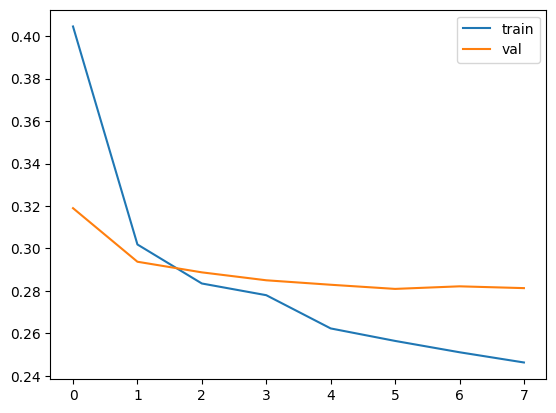

In [211]:
#plotting visuals to confirm model had good balance
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["train","val"])
plt.show()

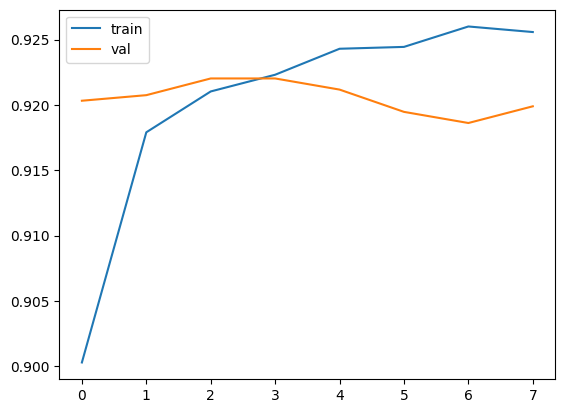

In [212]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["train","val"])
plt.show()

In [213]:
#loss and accuracy trained and balance
#this shows i did preprocessing right and model balance 
#dataset has majority no diabetes which helps model easy to learn

In [214]:
#Evaluating against proper metrics
y_proba = model.predict(X_val_tensor)
y_pred = np.argmax(y_proba, axis=1)

y_true = y_val_int  
print("F1:", f1_score(y_true, y_pred, average="weighted"))

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1: 0.9072743434745779


In [215]:
y_proba = model.predict(X_val_tensor)
y_true = y_val_int   
roc = roc_auc_score(y_true, y_proba, multi_class="ovr")
print("ROC:", roc)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ROC: 0.8490703669965792


In [216]:
y_proba = model.predict(X_val_tensor)
y_pred = np.argmax(y_proba, axis=1)
y_true = y_val_int
cm = confusion_matrix(y_true, y_pred)
print(cm)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[   0   10   45]
 [   2  134   88]
 [   4   39 2025]]


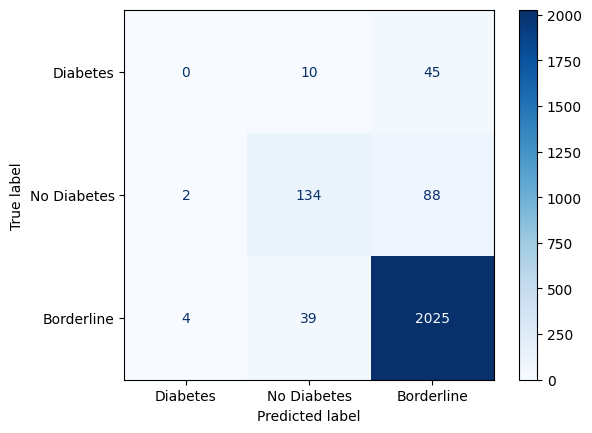

In [217]:
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Diabetes", "No Diabetes", "Borderline"])
cm_display.plot(cmap="Blues")

In [218]:
#recalbiration of label data caused by label encoder should be 0 1 2
#Confusion matrix shows not much data for borderline but still helpful data

In [219]:
#Applying Monte Carlo Dropout - probabilistic method
tf.keras.layers.Dropout(0.3)

def monte_carlo_dropout(model, X_val_tensor, passes=50):
    predictions = []
    for _ in range(passes):
        preds = model(X_val_tensor, training=True)
        predictions.append(preds)
        
    stacked = tf.stack(predictions)
    return stacked.numpy()  

In [220]:
#Setting up calculation for predictive mean and variance
mc = monte_carlo_dropout(model, X_val_tensor, passes=50)

mean_preds = mc.mean(axis=0)
var_preds  = mc.var(axis=0)

In [221]:
print("Mean preds shape:", mean_preds.shape)
print("Var preds shape:",  var_preds.shape)

print("Mean preds:")
print(mean_preds[:10])

print("Var preds:")
print(var_preds[:10])

Mean preds shape: (2347, 3)
Var preds shape: (2347, 3)
Mean preds:
[[3.5878152e-02 3.1649228e-02 9.3247229e-01]
 [8.1868842e-04 6.3959928e-04 9.9854189e-01]
 [8.9834100e-03 9.6194129e-03 9.8139685e-01]
 [1.3678926e-02 2.2349849e-02 9.6397048e-01]
 [1.3725280e-02 1.0753014e-02 9.7552139e-01]
 [1.8824860e-02 5.5428338e-03 9.7563201e-01]
 [1.6536542e-03 1.9737708e-03 9.9637228e-01]
 [8.1462339e-03 3.9534811e-02 9.5231909e-01]
 [5.1454888e-03 1.7490920e-02 9.7736359e-01]
 [5.3765285e-03 2.6597226e-02 9.6802622e-01]]
Var preds:
[[4.9960036e-16 5.5511151e-17 1.2789769e-13]
 [0.0000000e+00 8.4703295e-20 3.1974423e-14]
 [7.8062556e-18 3.1225023e-17 8.8817842e-14]
 [1.3877788e-17 2.2204460e-16 4.2987836e-13]
 [2.1684043e-17 3.1225023e-17 1.2789769e-13]
 [8.6736174e-17 2.1684043e-19 1.2789769e-13]
 [1.2197274e-19 5.4210109e-20 1.7408297e-13]
 [3.4694470e-18 5.5511151e-17 3.1974423e-14]
 [5.4210109e-18 3.1225023e-17 0.0000000e+00]
 [5.4210109e-18 1.3877788e-17 3.5527137e-15]]


In [224]:
#Model confidence is high for class 2 no diabetes 93%
#and variance is low for class 2. model is stable and confident

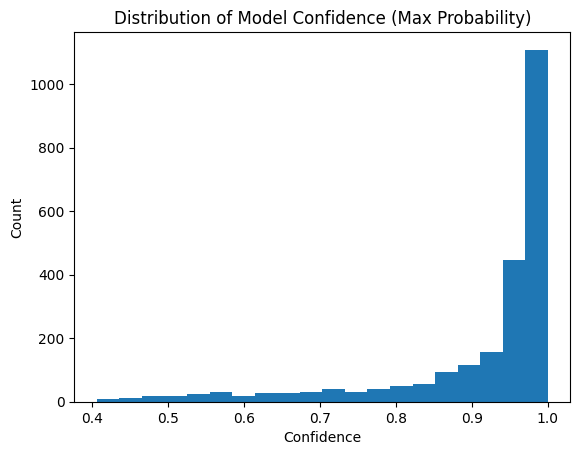

In [225]:
#plotting confidence and variance
max_probs = mean_preds.max(axis=1)

plt.hist(max_probs, bins=20)
plt.title("Distribution of Model Confidence (Max Probability)")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()

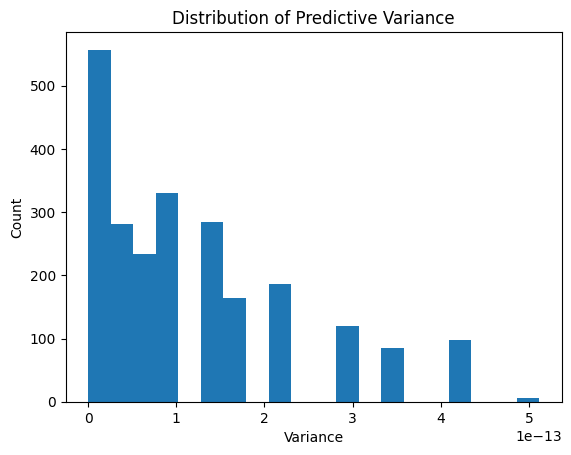

In [226]:
var_scores = var_preds.max(axis=1)

plt.hist(var_scores, bins=20)
plt.title("Distribution of Predictive Variance")
plt.xlabel("Variance")
plt.ylabel("Count")
plt.show()

In [227]:
#Comparing against Confidence Interval
# how confident is model on class2?
std_preds = np.sqrt(var_preds)
lower = mean_preds - 1.96 * std_preds
upper = mean_preds + 1.96 * std_preds

In [228]:
print("Lower CI:")
print(lower[:10])

print("\nUpper CI:")
print(upper[:10])

Lower CI:
[[3.58781070e-02 3.16492133e-02 9.32471573e-01]
 [8.18688422e-04 6.39598700e-04 9.98541534e-01]
 [8.98340438e-03 9.61940177e-03 9.81396258e-01]
 [1.36789186e-02 2.23498195e-02 9.63969171e-01]
 [1.37252705e-02 1.07530029e-02 9.75520670e-01]
 [1.88248418e-02 5.54283289e-03 9.75631297e-01]
 [1.65365345e-03 1.97377033e-03 9.96371448e-01]
 [8.14623013e-03 3.95347960e-02 9.52318728e-01]
 [5.14548412e-03 1.74909085e-02 9.77363586e-01]
 [5.37652383e-03 2.65972186e-02 9.68026102e-01]]

Upper CI:
[[3.58781964e-02 3.16492431e-02 9.32473004e-01]
 [8.18688422e-04 6.39599864e-04 9.98542249e-01]
 [8.98341555e-03 9.61942412e-03 9.81397450e-01]
 [1.36789335e-02 2.23498791e-02 9.63971794e-01]
 [1.37252891e-02 1.07530253e-02 9.75522101e-01]
 [1.88248791e-02 5.54283476e-03 9.75632727e-01]
 [1.65365485e-03 1.97377126e-03 9.96373117e-01]
 [8.14623758e-03 3.95348258e-02 9.52319443e-01]
 [5.14549343e-03 1.74909309e-02 9.77363586e-01]
 [5.37653314e-03 2.65972335e-02 9.68026340e-01]]


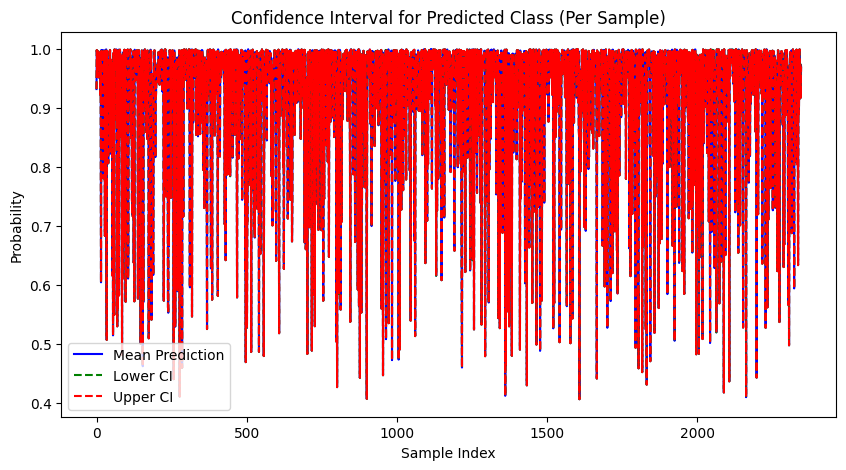

In [229]:
pred_class = mean_preds.argmax(axis=1)

mean_pred_class  = mean_preds[np.arange(len(mean_preds)), pred_class]
lower_pred_class = lower[np.arange(len(lower)), pred_class]
upper_pred_class = upper[np.arange(len(upper)), pred_class]

plt.figure(figsize=(10,5))
plt.plot(mean_pred_class, label="Mean Prediction", color="blue")
plt.plot(lower_pred_class, label="Lower CI", color="green", linestyle="--")
plt.plot(upper_pred_class, label="Upper CI", color="red", linestyle="--")

plt.title("Confidence Interval for Predicted Class (Per Sample)")
plt.xlabel("Sample Index")
plt.ylabel("Probability")
plt.legend()
plt.show()

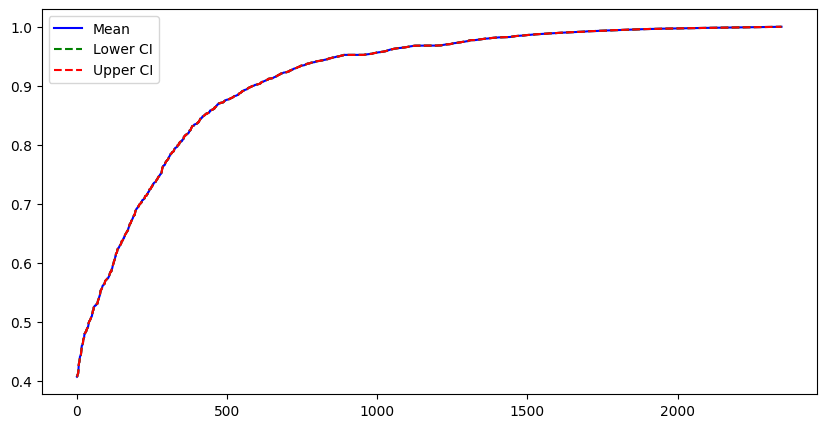

In [230]:
order = np.argsort(mean_pred_class)

plt.figure(figsize=(10,5))
plt.plot(mean_pred_class[order], label="Mean", color="blue")
plt.plot(lower_pred_class[order], label="Lower CI", color="green", linestyle="--")
plt.plot(upper_pred_class[order], label="Upper CI", color="red", linestyle="--")
plt.legend()
plt.show()

In [232]:
model.save("diabetesgen.keras")

In [233]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)